# Proyecto de series de tiempo.
### Promedio de la magnitud de sismos registrados cada dia de 2024 a 2025 en México.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
warnings.filterwarnings('ignore')

# Análisis Exploratorio

In [4]:
sismosdf = pd.read_csv('2020-2021.csv', skiprows=4)
sismosdf.head()

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2020-01-01,00:06:09,3.4,16.3972,-97.4925,6.1,"43 km al NORTE de RIO GRANDE, OAX",2020-01-01,06:06:09,revisado
1,2020-01-01,00:10:19,4.0,18.1212,-103.3780,14.6,"76 km al SUROESTE de COALCOMAN, MICH",2020-01-01,06:10:19,revisado
2,2020-01-01,00:33:22,3.2,16.3887,-97.5088,3.6,"43 km al NORTE de RIO GRANDE, OAX",2020-01-01,06:33:22,revisado
3,2020-01-01,00:48:08,3.8,16.5347,-91.1040,33.0,"97 km al ESTE de LAS MARGARITAS, CHIS",2020-01-01,06:48:08,revisado
4,2020-01-01,00:59:13,3.3,16.0057,-97.4523,29.7,"2 km al SUROESTE de RIO GRANDE, OAX",2020-01-01,06:59:13,revisado


In [5]:
sismosdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 59167 entries, 0 to 59166
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fecha                       59167 non-null  str    
 1   Hora                        59160 non-null  str    
 2   Magnitud                    59160 non-null  float64
 3   Latitud                     59160 non-null  float64
 4   Longitud                    59160 non-null  float64
 5   Profundidad                 59160 non-null  float64
 6   Referencia de localizacion  59160 non-null  str    
 7   Fecha UTC                   59160 non-null  str    
 8   Hora UTC                    59160 non-null  str    
 9   Estatus                     59160 non-null  str    
dtypes: float64(4), str(6)
memory usage: 4.5 MB


## Variable objetivo y unidades
Variable objetivo: Magnitud.

Unidades: La magnitud de un sismo es adimensional. Se calcula mediante fórmulas matemáticas distintas.

Magnitud coda (Mc): Sismos menores de 4.5

Magnitud de momento (Mw): Sismos mayores de 4.5

Magnitud de energía (ME): Sismos mayores de 4.5 con epicentro en Guerrero.

Magnitud de amplitud (MA): Sismos en México.

In [6]:
sismosdf['Fecha'] = pd.to_datetime(sismosdf['Fecha'], errors='coerce')
sismosdf = sismosdf.dropna(subset=['Fecha'])

promedio_magnitud = (
    sismosdf
    .groupby('Fecha')['Magnitud']
    .mean()
    .reset_index()
)

promedio_magnitud.head()

,Fecha,Magnitud
0,2020-01-01,3.628736
1,2020-01-02,3.604110
2,2020-01-03,3.677778
3,2020-01-04,3.618056
4,2020-01-05,3.735526


## Formato y rango de tiempo

Formato: Originalmente, se tienen datos diarios en distintos momentos. Sin embargo, se limpió el conjunto de datos para que el formato sea cada día, pero, no se cumple necesariamente un periodo de 24 horas.

Lo que si es un hecho, es que la fecha y hora estan en el tiempo del Centro de México.
Rango de tiempo: Desde 01/01/2020 hasta 31/12/2021

In [7]:
serie_magnitud = promedio_magnitud['Magnitud']
serie_magnitud

0      3.628736
1      3.604110
2      3.677778
3      3.618056
4      3.735526
         ...   
726    3.664789
727    3.561856
728    3.511268
729    3.474667
730    3.434118
Name: Magnitud, Length: 731, dtype: float64

## Cantidad de puntos

In [8]:
sismosdf.isnull().sum()

Fecha                         0
Hora                          0
Magnitud                      0
Latitud                       0
Longitud                      0
Profundidad                   0
Referencia de localizacion    0
Fecha UTC                     0
Hora UTC                      0
Estatus                       0
dtype: int64

In [9]:
promedio_magnitud.isnull().sum()

Fecha       0
Magnitud    0
dtype: int64

## Exploración

In [10]:
#Promedio de la magnitud por mes
promedio_magnitud['Mes'] = pd.to_datetime(promedio_magnitud['Fecha']).dt.month
promedio_magnitud.groupby('Mes')['Magnitud'].describe()

,count,mean,std,min,25%,50%,75%,max
Mes,,,,,,,,
1,62.0,3.599284,0.051046,3.454787,3.570147,3.602892,3.627970,3.735526
2,57.0,3.573097,0.059378,3.408108,3.540810,3.567717,3.611765,3.689754
3,62.0,3.581605,0.055860,3.422034,3.542018,3.578732,3.617910,3.701515
4,60.0,3.640749,0.059564,3.512329,3.604475,3.638221,3.687959,3.758000
5,62.0,3.577979,0.054913,3.429630,3.540216,3.584182,3.621067,3.706410
6,60.0,3.566945,0.082376,3.312903,3.527303,3.556826,3.594415,3.846087
7,62.0,3.574533,0.079858,3.377500,3.537692,3.565833,3.620160,3.775641
8,62.0,3.568708,0.060791,3.443860,3.523563,3.561551,3.615462,3.693827
9,60.0,3.550008,0.084281,3.358861,3.475507,3.547464,3.622525,3.778667


In [11]:
promedio_magnitud['Magnitud'].max() #sismo con mayor media de magnitud registrado en el dataset

np.float64(3.8460869565217393)

In [12]:
promedio_magnitud['Año'] = pd.to_datetime(promedio_magnitud['Fecha']).dt.year

In [13]:
varianza_anual = (promedio_magnitud.groupby('Año')['Magnitud'].var())
varianza_anual

Año
2020    0.004168
2021    0.004910
Name: Magnitud, dtype: float64

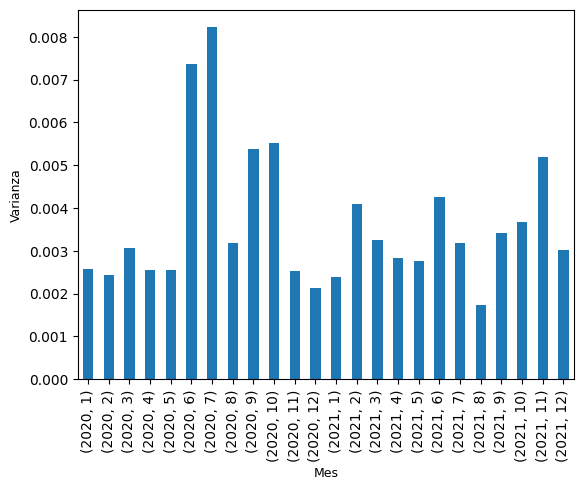

In [14]:
varianza_mes_anio = (promedio_magnitud.groupby(['Año', 'Mes'])['Magnitud'].var())

varianza_mes_anio.plot(kind='bar')
plt.xlabel('Mes', fontsize=9)
plt.ylabel('Varianza', fontsize=9)
plt.show()

# Análisis estadístico

In [15]:
# Estadísticas generales de magnitud
print("Estadísticas descriptivas de Magnitud:")
print(promedio_magnitud['Magnitud'].describe())

Estadísticas descriptivas de Magnitud:
count    731.000000
mean       3.578295
std        0.070997
min        3.312903
25%        3.534365
50%        3.577027
75%        3.624300
max        3.846087
Name: Magnitud, dtype: float64


In [16]:
promedio_magnitud.describe()

,Fecha,Magnitud,Mes,Año
count,731,731.000000,731.000000,731.000000
mean,2020-12-31 00:00:00,3.578295,6.519836,2020.499316
min,2020-01-01 00:00:00,3.312903,1.000000,2020.000000
25%,2020-07-01 12:00:00,3.534365,4.000000,2020.000000
50%,2020-12-31 00:00:00,3.577027,7.000000,2020.000000
75%,2021-07-01 12:00:00,3.624300,10.000000,2021.000000
max,2021-12-31 00:00:00,3.846087,12.000000,2021.000000
std,NaN,0.070997,3.451913,0.500342


## Medidas de tendencia central

In [17]:
media = np.mean(promedio_magnitud['Magnitud']) #moda
print(promedio_magnitud['Magnitud'].round(1).mode())

0    3.6
Name: Magnitud, dtype: float64


## Medidas de dispersión

In [18]:
np.var(promedio_magnitud['Magnitud']) #varianza

np.float64(0.005033703135707592)

In [19]:
desv = np.std(promedio_magnitud['Magnitud']) #desviacion estandar
desv

np.float64(0.0709485950227881)

In [20]:
cv = (desv / media) * 100 #coeficiente de variacion
cv

np.float64(1.9827485984626052)

In [21]:
promedio_magnitud['Magnitud'].max() - promedio_magnitud['Magnitud'].min() #rango

np.float64(0.5331837307152876)

## Gráfica de serie de tiempo original

In [22]:
#División de los datos por la fecha 
promedio_magnitud['Mes'] = promedio_magnitud['Fecha'].dt.month #extraemos el mes de la fecha
promedio_magnitud['Año'] = promedio_magnitud['Fecha'].dt.year #extraemos el año de la fecha
promedio_magnitud['Dia'] = promedio_magnitud['Fecha'].dt.day #extraemos el dia de la fecha
promedio_magnitud['Dia_semana'] = promedio_magnitud['Fecha'].dt.day_name() #extraemos el dia de la semana de la fecha

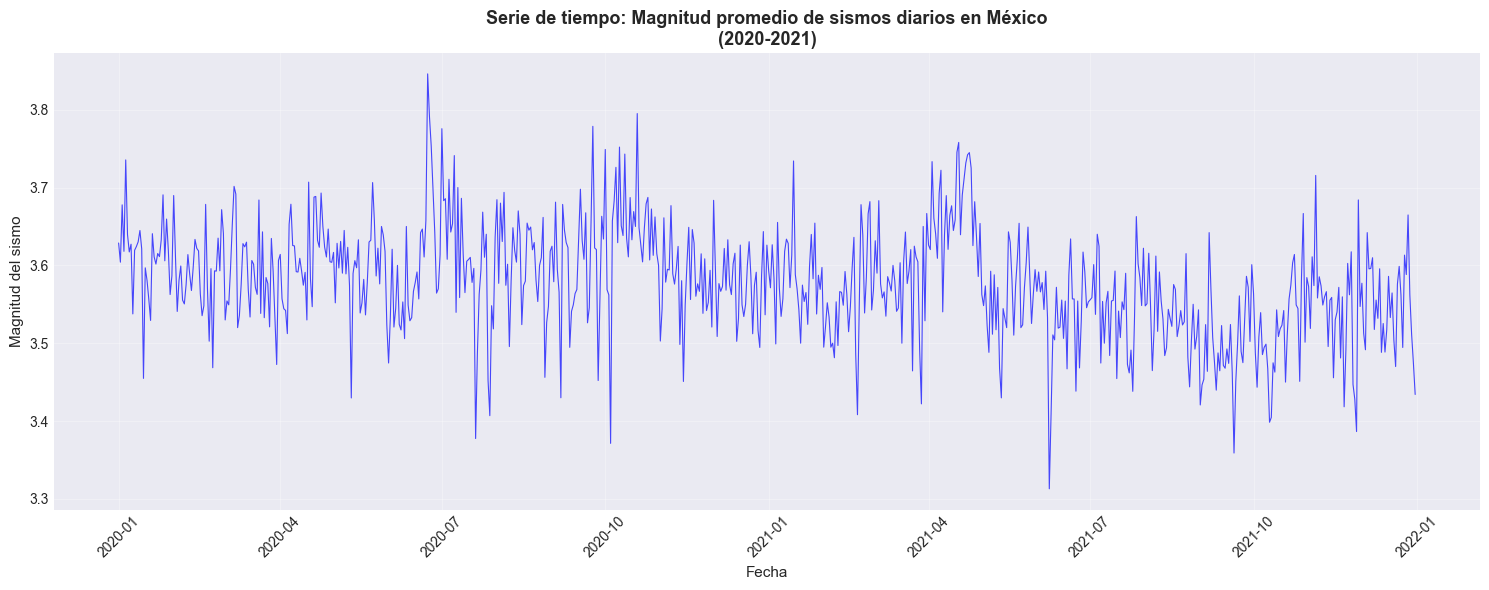

In [23]:
# 5. Visualización de la serie de tiempo original
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Gráfica de serie de tiempo original
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(promedio_magnitud['Fecha'], promedio_magnitud['Magnitud'],
        linewidth=0.8, alpha=0.7, color='blue')
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Magnitud del sismo', fontsize=11)
ax.set_title('Serie de tiempo: Magnitud promedio de sismos diarios en México\n(2020-2021)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# COMPONENTE DETERMINISTA

# Análisis de los componentes

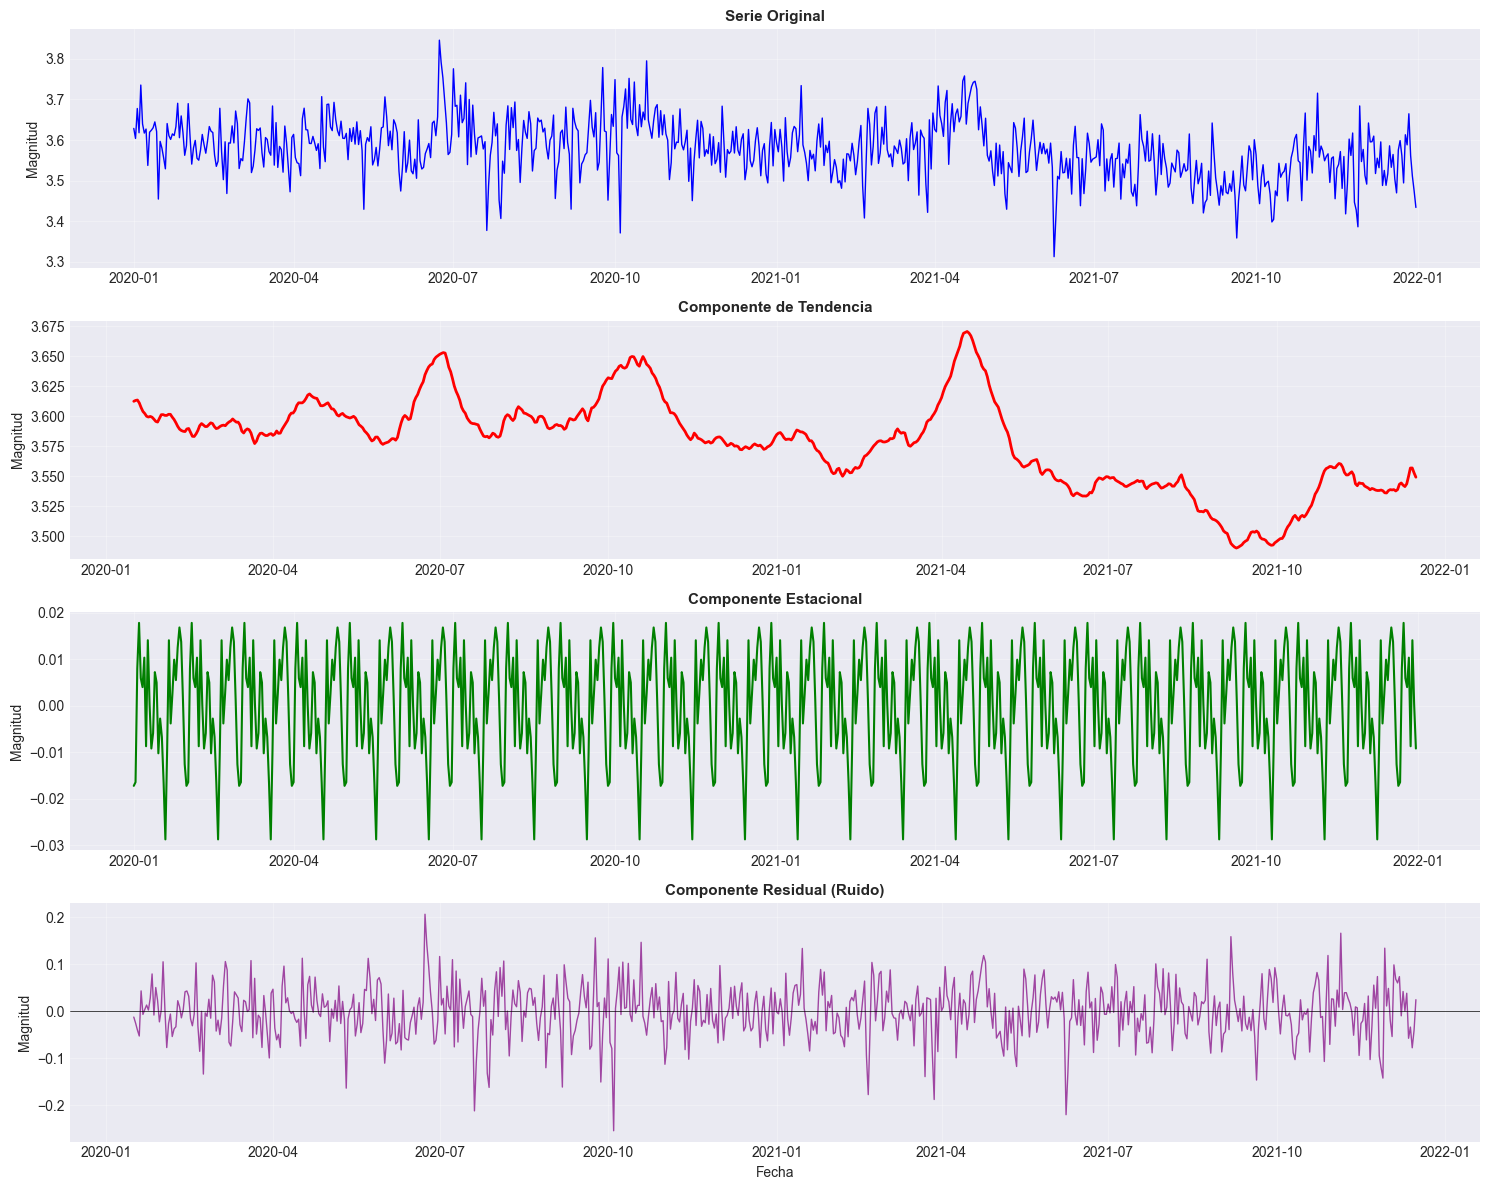

In [24]:
#frecuencia diaria
sismos_ts = promedio_magnitud.set_index('Fecha')['Magnitud'].sort_index()

#fechas completas
fechas_completas = pd.date_range(start=sismos_ts.index.min(), end=sismos_ts.index.max(), freq='D')
sismos_ts = sismos_ts.reindex(fechas_completas)

#Interpolacion de valores faltantes (si existen)
if sismos_ts.isnull().any():
    sismos_ts = sismos_ts.interpolate(method='linear')
    print(f"Se interpolaron {sismos_ts.isnull().sum()} valores faltantes")

#Descomposicion
descomposicion = seasonal_decompose(sismos_ts, model='additive', period=30)  # period=30 para estacionalidad mensual
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12))

# Original
ax1.plot(sismos_ts.index, sismos_ts, color='blue', linewidth=1)
ax1.set_title('Serie Original', fontsize=11, fontweight='bold')
ax1.set_ylabel('Magnitud')
ax1.grid(True, alpha=0.3)

# Tendencia
ax2.plot(descomposicion.trend.index, descomposicion.trend, color='red', linewidth=2)
ax2.set_title('Componente de Tendencia', fontsize=11, fontweight='bold')
ax2.set_ylabel('Magnitud')
ax2.grid(True, alpha=0.3)

# Estacionalidad
ax3.plot(descomposicion.seasonal.index, descomposicion.seasonal, color='green', linewidth=1.5)
ax3.set_title('Componente Estacional', fontsize=11, fontweight='bold')
ax3.set_ylabel('Magnitud')
ax3.grid(True, alpha=0.3)

# Residuos
ax4.plot(descomposicion.resid.index, descomposicion.resid, color='purple', linewidth=1, alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_title('Componente Residual (Ruido)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Magnitud')
ax4.set_xlabel('Fecha')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Análisis estadístico de componentes

In [25]:
print("Estadísticas de los componentes de descomposición:")
print("\nComponente de Tendencia:")
print(descomposicion.trend.describe())
print("\nComponente Estacional:")
print(descomposicion.seasonal.describe())
print("\nComponente Residual:")
print(descomposicion.resid.describe())

# Varianza explicada por cada componente
varianza_total = np.var(sismos_ts.dropna())
varianza_tendencia = np.var(descomposicion.trend.dropna())
varianza_estacional = np.var(descomposicion.seasonal.dropna())
varianza_residual = np.var(descomposicion.resid.dropna())

print("\n--- Varianza explicada por cada componente ---")
print(f"Varianza total: {varianza_total:.4f}")
print(f"Varianza tendencia: {varianza_tendencia:.4f} ({varianza_tendencia/varianza_total*100:.2f}%)")
print(f"Varianza estacional: {varianza_estacional:.4f} ({varianza_estacional/varianza_total*100:.2f}%)")
print(f"Varianza residual: {varianza_residual:.4f} ({varianza_residual/varianza_total*100:.2f}%)")

Estadísticas de los componentes de descomposición:

Componente de Tendencia:
count    701.000000
mean       3.578228
std        0.037423
min        3.490172
25%        3.549971
50%        3.582652
75%        3.600030
max        3.670583
Name: trend, dtype: float64

Componente Estacional:
count    731.000000
mean       0.000012
std        0.011640
min       -0.028762
25%       -0.009225
50%        0.002546
75%        0.009872
max        0.017781
Name: seasonal, dtype: float64

Componente Residual:
count    701.000000
mean      -0.000016
std        0.056967
min       -0.254735
25%       -0.033449
50%        0.000459
75%        0.035133
max        0.206059
Name: resid, dtype: float64

--- Varianza explicada por cada componente ---
Varianza total: 0.0050
Varianza tendencia: 0.0014 (27.78%)
Varianza estacional: 0.0001 (2.69%)
Varianza residual: 0.0032 (64.38%)


# Análisis de componentes con medias moviles

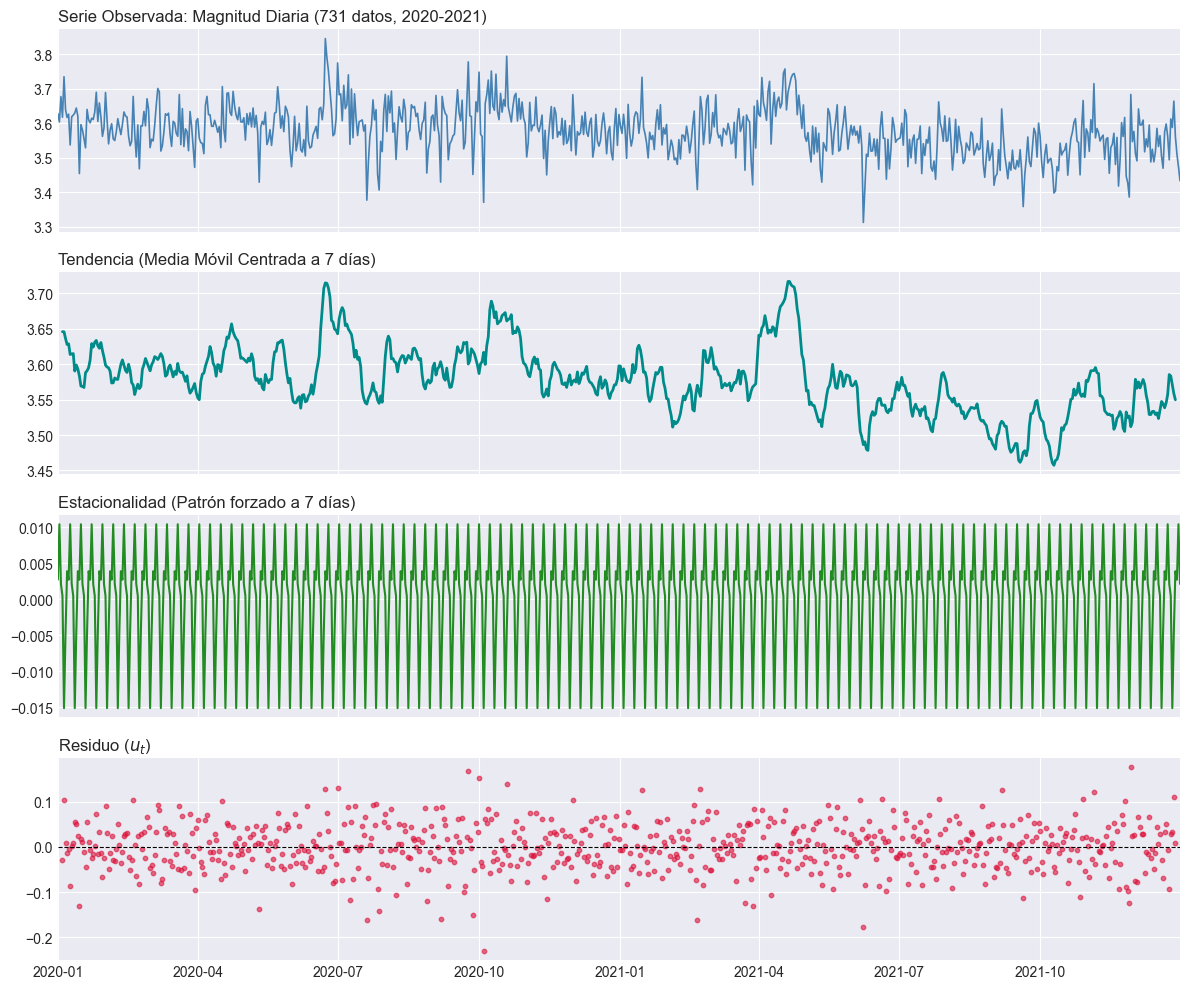

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Definicion de fechas
fechas_exactas = pd.date_range(start='2020-01-01', end='2021-12-31', freq='D')

sismos_ts = promedio_magnitud.set_index('Fecha')['Magnitud']

sismos_ts = sismos_ts.reindex(fechas_exactas)
ts = sismos_ts.interpolate(method='linear')
ts.name = "Magnitud"

# Desomposición para 365 dias
descomposicion = seasonal_decompose(ts, model='additive', period=7)

colores = {
    'observed': 'steelblue',
    'trend': 'darkcyan',
    'seasonal': 'forestgreen',
    'resid': 'crimson'
}

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].set_xlim([fechas_exactas.min(), fechas_exactas.max()])

# Componente Observado
axes[0].plot(ts.index, ts, color=colores['observed'], lw=1.2)
axes[0].set_title('Serie Observada: Magnitud Diaria (731 datos, 2020-2021)', loc='left', fontsize=12)

# Componente Tendencia
axes[1].plot(descomposicion.trend.index, descomposicion.trend, color=colores['trend'], lw=2)
axes[1].set_title('Tendencia (Media Móvil Centrada a 7 días)', loc='left', fontsize=12)

# Componente Estacional
axes[2].plot(descomposicion.seasonal.index, descomposicion.seasonal, color=colores['seasonal'], lw=1.5)
axes[2].set_title('Estacionalidad (Patrón forzado a 7 días)', loc='left', fontsize=12)

# Componente Residuo
axes[3].scatter(descomposicion.resid.index, descomposicion.resid, color=colores['resid'], s=10, alpha=0.6)
axes[3].axhline(0, color='black', lw=0.8, ls='--')
axes[3].set_title('Residuo ($u_t$)', loc='left', fontsize=12)

plt.tight_layout()
plt.show()

# Análisis de Estacionariedad

## Prueba Dickey-Fuller aumentado (ADF)

Número máximo de rezagos evaluados (Regla de Schwert): 19

ADF Con constante (c)
Estadístico ADF    : -4.9337
p-valor            : 0.000030
Rezagos usados     : 6
Valores críticos   : 1%: -3.439  5%: -2.866  10%: -2.569
1%: Se rechaza H0 → Serie ESTACIONARIA
5%: Se rechaza H0 → Serie ESTACIONARIA
10%: Se rechaza H0 → Serie ESTACIONARIA




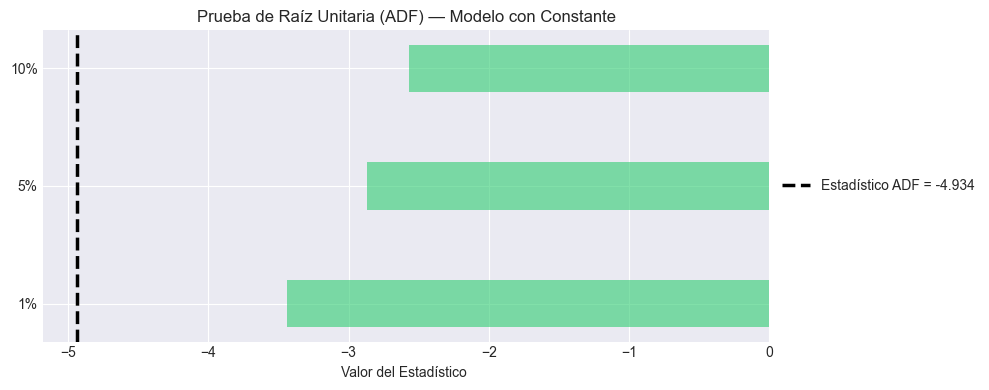

In [27]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

n_obs=731
# Regla de Schwert para máximo número de rezagos
p_max = int(12 * (n_obs / 100) ** 0.25)

print(f"Número máximo de rezagos evaluados (Regla de Schwert): {p_max}\n")


adf_c = adfuller(
    ts,
    maxlag=p_max,
    autolag='AIC',
    regression='c'
)

def interpretar(res, label):

    print(f"ADF {label}")
    print(f"Estadístico ADF    : {res[0]:.4f}")
    print(f"p-valor            : {res[1]:.6f}")
    print(f"Rezagos usados     : {res[2]}")

    print(
        "Valores críticos   : "
        + "  ".join(
            [f"{k}: {v:.3f}" for k, v in res[4].items()]
        )
    )

    for nivel in ['1%', '5%', '10%']:

        if res[0] < res[4][nivel]:
            print(f"{nivel}: Se rechaza H0 → Serie ESTACIONARIA")

        else:
            print(f"{nivel}: No se rechaza H0 → Serie NO estacionaria")

    print("\n")

interpretar(adf_c, "Con constante (c)")

fig, ax = plt.subplots(figsize=(10, 4))

criticos = adf_c[4]

niveles = list(criticos.keys())
valores = list(criticos.values())

colores = [
    '#2ecc71' if adf_c[0] < v else '#e74c3c'
    for v in valores
]

ax.barh(
    niveles,
    valores,
    color=colores,
    alpha=0.6,
    height=0.4
)

ax.axvline(
    adf_c[0],
    color='black',
    linewidth=2.5,
    linestyle='--',
    label=f'Estadístico ADF = {adf_c[0]:.3f}'
)

ax.set_xlabel(
    'Valor del Estadístico '
)

ax.set_title(
    'Prueba de Raíz Unitaria (ADF) — Modelo con Constante'
)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

# Análisis de  Autocorrelación

## ACF

In [28]:
serie = promedio_magnitud['Magnitud']

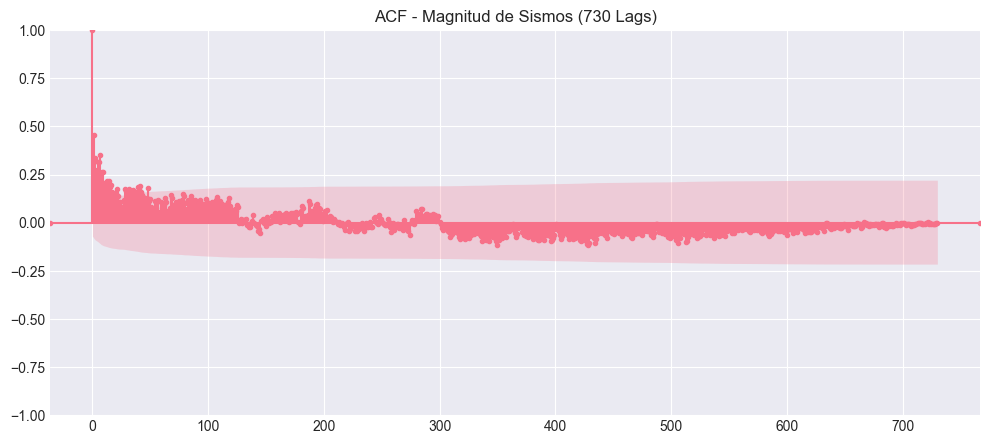

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
# vlines=False quita las líneas verticales densas
plot_acf(serie, lags=730, ax=ax, marker='o', markersize=3)
ax.set_title('ACF - Magnitud de Sismos (730 Lags)')
plt.show()

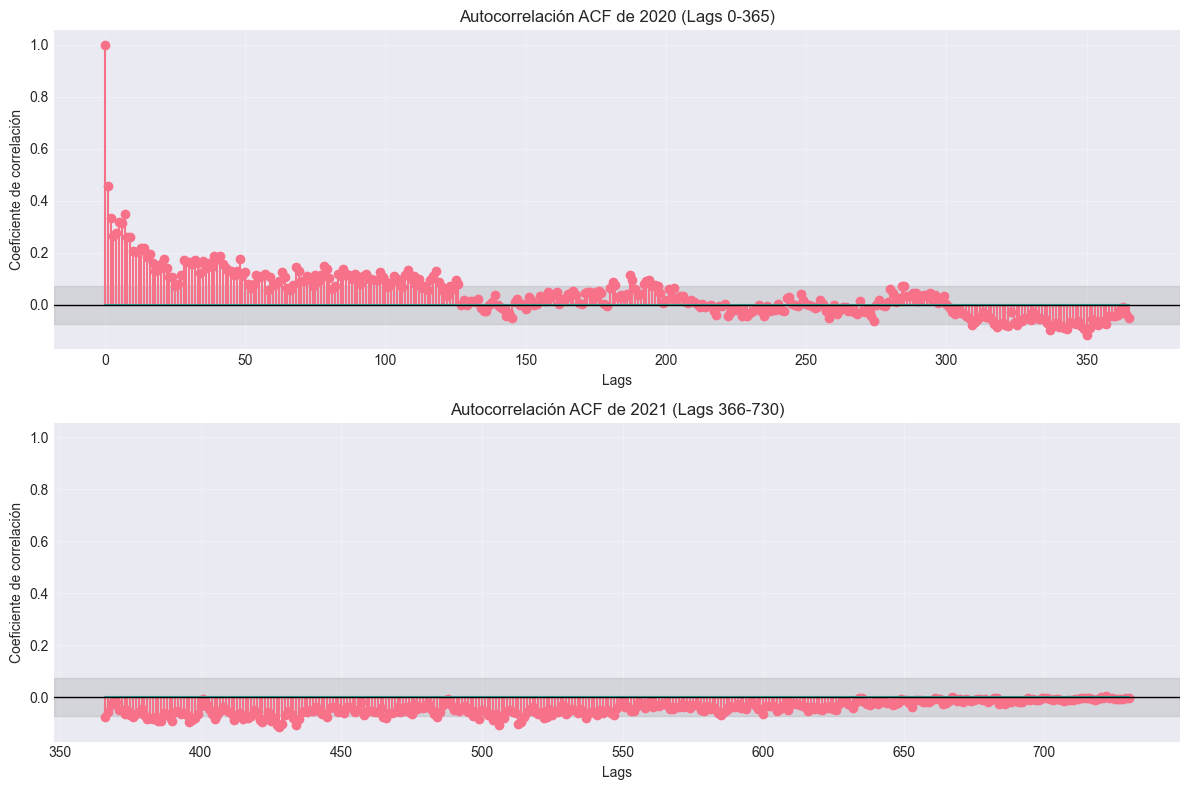

In [30]:
valores_acf = acf(serie, nlags=730)
n = len(serie)
banda = 1.96 / np.sqrt(n)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharey=True)
banda = 1.96 / np.sqrt(n)

ax1.stem(range(366), valores_acf[:366]) #366 lags para 2024
ax1.axhspan(-banda, banda, alpha=0.2, color='gray', label='Banda de confianza (95%)')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title("Autocorrelación ACF de 2020 (Lags 0-365)")
ax1.set_xlabel('Lags')
ax1.set_ylabel('Coeficiente de correlación')
ax1.grid(True, alpha=0.3)

ax2.stem(range(366, 731), valores_acf[366:]) #365 lags para 2025
ax2.axhspan(-banda, banda, alpha=0.2, color='gray')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title("Autocorrelación ACF de 2021 (Lags 366-730)")
ax2.set_xlabel('Lags')
ax2.set_ylabel('Coeficiente de correlación')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Correlograma de Calor

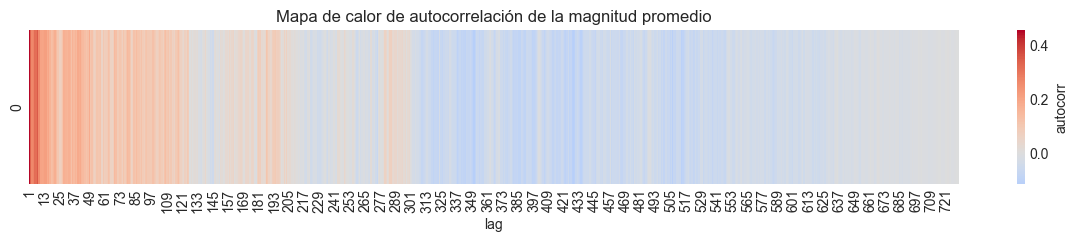

In [31]:
lags = 730
acf_values = acf(serie, nlags= lags)
df_acf = pd.DataFrame(acf_values[1:].reshape(1, -1), 
                      columns=range(1, lags + 1))

plt.figure(figsize=(15, 2))
sns.heatmap(df_acf, annot=False, cmap='coolwarm', center=0,      
            cbar_kws={'label': 'autocorr'})

plt.title('Mapa de calor de autocorrelación de la magnitud promedio')
plt.xlabel('lag')
plt.show()

El pasado va perdiendo importancia en el presente (correlación)

## PACF

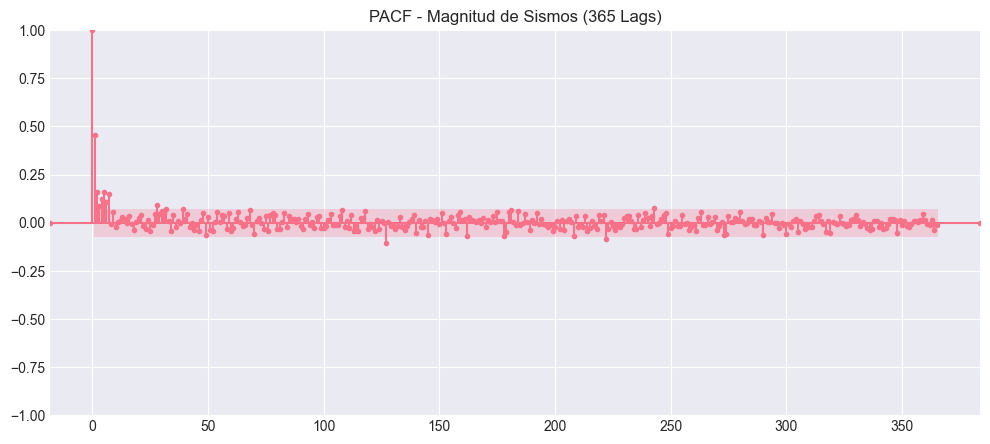

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
# vlines=False quita las líneas verticales densas
plot_pacf(serie, lags=365, ax=ax, marker='o', markersize=3)
ax.set_title('PACF - Magnitud de Sismos (365 Lags)')
plt.show()

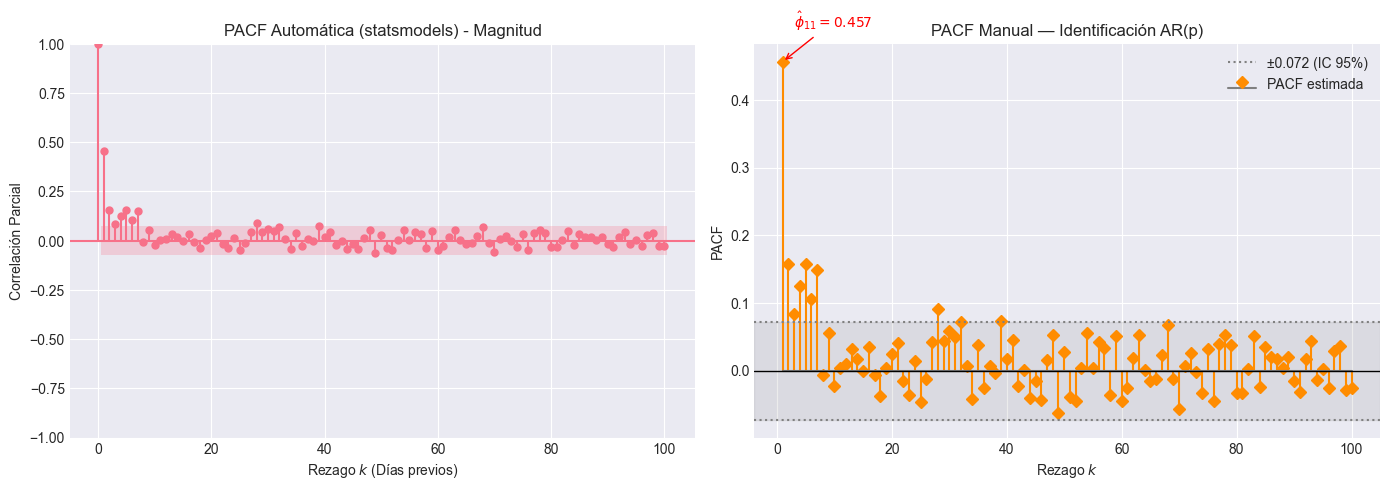

Análisis de Identificación del Modelo AR:
------------------------------------------------------------
PACF en rezago 1: 0.4565
Rezagos significativos iniciales (consecutivos): [1, 2, 3, 4, 5, 6, 7]
Orden AR(p) sugerido: p = 7 (corte en PACF)


In [33]:
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

ts_clean = ts.dropna()
n_obs = len(ts_clean)

lags_max = min(100, int(n_obs / 4))

banda = 1.96 / np.sqrt(n_obs)

# Método Yule-Walker modificado
pacf_vals = pacf(ts_clean, nlags=lags_max, method='ywm')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1
plot_pacf(ts_clean, lags=lags_max, ax=axes[0], method='ywm',
          title='PACF Automática (statsmodels) - Magnitud')
axes[0].set_xlabel('Rezago $k$ (Días previos)')
axes[0].set_ylabel('Correlación Parcial')

# Panel 2
k_vals = np.arange(1, lags_max + 1)
axes[1].stem(k_vals, pacf_vals[1:], linefmt='darkorange', markerfmt='D',
             basefmt='gray', label='PACF estimada')

axes[1].axhspan(-banda, banda, alpha=0.15, color='gray')
axes[1].axhline(banda, color='gray', linestyle=':', linewidth=1.5,
                label=f'±{banda:.3f} (IC 95%)')
axes[1].axhline(-banda, color='gray', linestyle=':', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=1)

# Anotación rezago 1
offset_y = 0.05 if pacf_vals[1] >= 0 else -0.05
axes[1].annotate(
    f'$\\hat{{\\phi}}_{{11}} = {pacf_vals[1]:.3f}$',
    xy=(1, pacf_vals[1]), xytext=(3, pacf_vals[1] + offset_y),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10, color='red'
)

axes[1].set_title('PACF Manual — Identificación AR(p)')
axes[1].set_xlabel('Rezago $k$')
axes[1].set_ylabel('PACF')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


print("Análisis de Identificación del Modelo AR:")
print("-" * 60)
print(f"PACF en rezago 1: {pacf_vals[1]:.4f}")

# CORRECCIÓN 2: detectar corte consecutivo
sig_flags = [abs(pacf_vals[k]) > banda for k in range(1, lags_max + 1)]

p_sugerido = 0
for i, flag in enumerate(sig_flags):
    if flag:
        p_sugerido += 1
    else:
        break  # aquí está la clave: cortar en el primer no significativo

print(f"Rezagos significativos iniciales (consecutivos): {list(range(1, p_sugerido+1)) if p_sugerido > 0 else 'Ninguno'}")

# CORRECCIÓN 3: lógica correcta
if p_sugerido == 0:
    print("Orden AR(p) sugerido: p = 0 (Ruido blanco)")
else:
    print(f"Orden AR(p) sugerido: p = {p_sugerido} (corte en PACF)")

## Prueba de Ljung-Box

Prueba de Ljung-Box sobre la Magnitud Diaria (y_t)
  Rezago h   Estadístico Q         p-valor                Conclusión
---------------------------------------------------------------------------
         5        415.8019 1.1642362697842123e-87 Rechaza H0 (Autocorrelación)
         6        488.8249 2.146797797688834e-102 Rechaza H0 (Autocorrelación)
        10        711.8825 1.7654989671679062e-146 Rechaza H0 (Autocorrelación)
        20        962.6731 3.537104911736614e-191 Rechaza H0 (Autocorrelación)
        50       1457.9580 2.1647587161187266e-272 Rechaza H0 (Autocorrelación)
       100       1887.5614             0.0 Rechaza H0 (Autocorrelación)
       150       2074.8392             0.0 Rechaza H0 (Autocorrelación)
       200       2198.3365             0.0 Rechaza H0 (Autocorrelación)
       300       2294.2050 1.5135891625510913e-303 Rechaza H0 (Autocorrelación)
       365       2648.2524             0.0 Rechaza H0 (Autocorrelación)
       730       4777.9831             

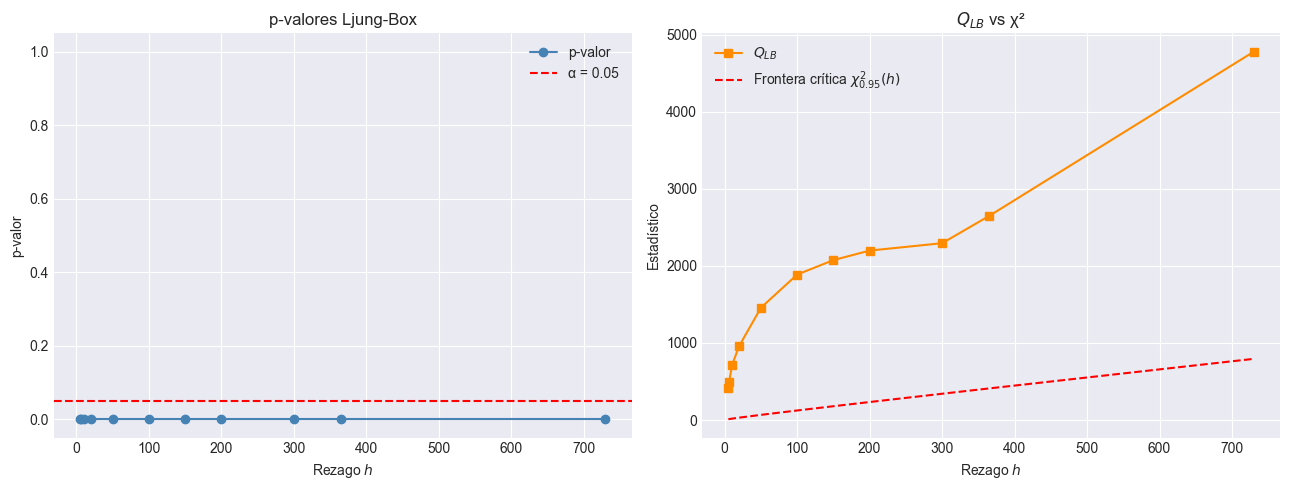

In [34]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

ts_clean = ts.dropna()
n = len(ts_clean)

# CORRECCIÓN 1: mejores rezagos (corto, medio y largo plazo)
lags_lb = sorted(set([5, 10, 20, 50, 100, 150, 200, 300, 365, 730, int(np.log(n))]))

# Evitar lags mayores que la serie
lags_lb = [h for h in lags_lb if h < n]

# Prueba de Ljung-Box
lb_result = acorr_ljungbox(ts_clean, lags=lags_lb, return_df=True)

print("Prueba de Ljung-Box sobre la Magnitud Diaria (y_t)")
print("=" * 75)
print(f"{'Rezago h':>10} {'Estadístico Q':>15} {'p-valor':>15} {'Conclusión':>25}")
print("-" * 75)

rechazos = 0

for index, row in lb_result.iterrows():
    q  = float(row['lb_stat'])
    p  = float(row['lb_pvalue'])
    
    if p < 0.05:
        c = 'Rechaza H0 (Autocorrelación)'
        rechazos += 1
    else:
        c = 'No rechaza H0 (Ruido blanco)'
    
    print(f"{int(index):>10} {q:>15.4f} {p:>15} {c:>25}")

# CORRECCIÓN 2: conclusión global
print("\nConclusión global:")
if rechazos > 0:
    print("La serie NO es ruido blanco (hay autocorrelación en al menos un rezago)")
else:
    print("La serie es consistente con ruido blanco")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: p-valores
axes[0].plot(lb_result.index, lb_result['lb_pvalue'].astype(float),
             'o-', color='steelblue', label='p-valor')
axes[0].axhline(0.05, color='red', linestyle='--', label='α = 0.05')
axes[0].set_xlabel('Rezago $h$')
axes[0].set_ylabel('p-valor')
axes[0].set_title('p-valores Ljung-Box')
axes[0].set_ylim([-0.05, 1.05])
axes[0].legend()

# Panel 2: Q vs chi-cuadrada
axes[1].plot(lb_result.index, lb_result['lb_stat'].astype(float),
             's-', color='darkorange', label='$Q_{LB}$')

chi2_crit = [stats.chi2.ppf(0.95, df=int(h)) for h in lb_result.index]
axes[1].plot(lb_result.index, chi2_crit, 'r--',
             label='Frontera crítica $\\chi^2_{0.95}(h)$')

axes[1].set_xlabel('Rezago $h$')
axes[1].set_ylabel('Estadístico')
axes[1].set_title('$Q_{LB}$ vs χ²')
axes[1].legend()

plt.tight_layout()
plt.show()

In [35]:
ts_clean = ts.dropna()
n_obs = len(ts_clean)
acf_vals = acf(ts_clean, nlags=5)

rho_hat_1 = acf_vals[1] 

# Cálculo matemático del estadístico Q_LB para h=1
qlb_1 = n_obs * (n_obs + 2) * (rho_hat_1**2) / (n_obs - 1)

print("--- Desglose Matemático: Prueba de Ljung-Box (h=1) ---")
print(f"Número de observaciones (n): {n_obs}")
print(f"ACF estimada en rezago 1 (ρ̂(1)): {rho_hat_1:.4f}")
print(f"\nCálculo exacto de Q_LB para h=1:")
print(f"  {n_obs} * ({n_obs} + 2) * ({rho_hat_1:.4f}^2) / ({n_obs} - 1)")
print(f"  = {n_obs * (n_obs + 2)} * {rho_hat_1**2:.6f} / {n_obs - 1}")
print(f"  = {qlb_1:.4f}\n")

# Para comparar, el p-valor para una distribución chi-cuadrada con 1 grado de libertad
p_val_1 = 1 - stats.chi2.cdf(qlb_1, df=1)

print("Resultado y Conclusión")
print(f"Estadístico Q_LB(1(: {qlb_1:.4f}")
print(f"p-valor asociado: {p_val_1:.6f}")

if p_val_1 < 0.05:
    print("Conclusión a h=1: Rechaza H0 (Hay dependencia del día inmediatamente anterior)")
else:
    print("Conclusión a h=1: No rechaza H0 (El rezago 1 es estadísticamente igual a cero)")

--- Desglose Matemático: Prueba de Ljung-Box (h=1) ---
Número de observaciones (n): 731
ACF estimada en rezago 1 (ρ̂(1)): 0.4565

Cálculo exacto de Q_LB para h=1:
  731 * (731 + 2) * (0.4565^2) / (731 - 1)
  = 535823 * 0.208430 / 730
  = 152.9884

Resultado y Conclusión
Estadístico Q_LB(1(: 152.9884
p-valor asociado: 0.000000
Conclusión a h=1: Rechaza H0 (Hay dependencia del día inmediatamente anterior)


# MODELO

## AR (1)

In [36]:
modelo_ar1 = ARIMA(ts_clean, order=(1,0,0)).fit()
print(modelo_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:               Magnitud   No. Observations:                  731
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 982.763
Date:                Mon, 18 May 2026   AIC                          -1959.526
Time:                        22:27:27   BIC                          -1945.742
Sample:                    01-01-2020   HQIC                         -1954.208
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5782      0.004    830.368      0.000       3.570       3.587
ar.L1          0.4588      0.030     15.054      0.000       0.399       0.519
sigma2         0.0040      0.000     21.740      0.0

## AR(7)

In [37]:
modelo_ar7 = ARIMA(ts_clean, order=(7,0,0)).fit()
print(modelo_ar7.summary())

                               SARIMAX Results                                
Dep. Variable:               Magnitud   No. Observations:                  731
Model:                 ARIMA(7, 0, 0)   Log Likelihood                1022.384
Date:                Mon, 18 May 2026   AIC                          -2026.768
Time:                        22:27:28   BIC                          -1985.418
Sample:                    01-01-2020   HQIC                         -2010.816
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5784      0.010    371.970      0.000       3.560       3.597
ar.L1          0.3076      0.035      8.687      0.000       0.238       0.377
ar.L2          0.0777      0.041      1.913      0.0

## ARMA(1, 1)

In [38]:
modelo_arma11 = ARIMA(ts, order=(1,0,1)).fit()
print(modelo_arma11.summary())

                               SARIMAX Results                                
Dep. Variable:               Magnitud   No. Observations:                  731
Model:                 ARIMA(1, 0, 1)   Log Likelihood                1006.966
Date:                Mon, 18 May 2026   AIC                          -2005.931
Time:                        22:27:28   BIC                          -1987.554
Sample:                    01-01-2020   HQIC                         -1998.842
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5781      0.010    358.740      0.000       3.559       3.598
ar.L1          0.9413      0.020     47.771      0.000       0.903       0.980
ma.L1         -0.7391      0.038    -19.681      0.0

## Análisis de residuos

# COMPONENTE ALEATORIO

In [39]:
comparacion = pd.DataFrame({
    'Modelo': ['AR(1)', 'AR(7)', 'ARMA(1,1)'],
    
    'AIC': [
        modelo_ar1.aic,
        modelo_ar7.aic,
        modelo_arma11.aic
    ],
    
    'BIC': [
        modelo_ar1.bic,
        modelo_ar7.bic,
        modelo_arma11.bic
    ],
    
    'Log-Likelihood': [
        modelo_ar1.llf,
        modelo_ar7.llf,
        modelo_arma11.llf
    ]
})

comparacion = comparacion.sort_values(by='AIC')
print("Ljung-Box sobre residuos")

modelos = {
    'AR(1)': modelo_ar1,
    'AR(7)': modelo_ar7,
    'ARMA(1,1)': modelo_arma11
}

for nombre, modelo in modelos.items():

    residuos = modelo.resid

    lb = acorr_ljungbox(
        residuos,
        lags=[10,20],
        return_df=True
    )

    print(f"\nModelo: {nombre}")
    print(lb)

Ljung-Box sobre residuos

Modelo: AR(1)
       lb_stat     lb_pvalue
10   84.130535  7.745172e-14
20  120.763615  2.058675e-16

Modelo: AR(7)
     lb_stat  lb_pvalue
10  2.476532   0.991213
20  4.924501   0.999754

Modelo: ARMA(1,1)
      lb_stat  lb_pvalue
10  38.704898   0.000029
20  44.272788   0.001383


# METRICAS

In [40]:
fit_ar1 = modelo_ar1.fittedvalues
fit_ar7 = modelo_ar7.fittedvalues
fit_arma11 = modelo_arma11.fittedvalues

ts_eval = ts.loc[fit_ar1.index]

metricas = pd.DataFrame({

    'Modelo': [
        'AR(1)',
        'AR(7)',
        'ARMA(1,1)'
    ],

    'AIC': [

        modelo_ar1.aic,

        modelo_ar7.aic,

        modelo_arma11.aic
    ],

    'BIC': [

        modelo_ar1.bic,

        modelo_ar7.bic,

        modelo_arma11.bic
    ],

    'RMSE': [

        np.sqrt(
            mean_squared_error(
                ts_eval,
                fit_ar1
            )
        ),

        np.sqrt(
            mean_squared_error(
                ts_eval,
                fit_ar7
            )
        ),

        np.sqrt(
            mean_squared_error(
                ts_eval,
                fit_arma11
            )
        )
    ],

    'MAE': [

        mean_absolute_error(
            ts_eval,
            fit_ar1
        ),

        mean_absolute_error(
            ts_eval,
            fit_ar7
        ),

        mean_absolute_error(
            ts_eval,
            fit_arma11
        )
    ]

})


metricas = metricas.sort_values('AIC')

print("\nComparación de métricas")
print(metricas.round(4))


Comparación de métricas
      Modelo        AIC        BIC    RMSE     MAE
1      AR(7) -2026.7679 -1985.4182  0.0597  0.0462
2  ARMA(1,1) -2005.9315 -1987.5538  0.0610  0.0466
0      AR(1) -1959.5257 -1945.7425  0.0631  0.0486
